<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- edad: Representa los años del cliente.
- nivel_ingreso: Estimación del ingreso del usuario.
- visitas_mes: Frecuencia de acceso a la plataforma.
- compras_mes: Volumen de transacciones mensuales.
- gasto_publicidad_dirigida: Inversión en marketing por usuario.
- satisfaccion: Escala de percepción (1 a 5).
- ingreso_anual: Variable objetivo (KPI económico).

Observación: 
La columna **edad** se encuentra como float64, lo cual es inusual para una variable que normalmente se expresa en años enteros; se podría considerar convertirla a int para mejorar la consistencia del análisis. 

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`:(1 = Sí, 0 = No)
- `abandono`:(1 = Sí, 0 = No).

Las siguientes columnas representan variables binarias y ya están codificadas como enteros (int64), lo cual facilita el cálculo de correlaciones inmediatas:
Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas (tipo object):
- `id_cliente`: Identificador alfanumérico único.
- `tipo_dispositivo`:Contiene 3 categorías (móvil, escritorio, tablet).
- `region`:Contiene 4 categorías (norte, sur, oeste, este).
Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas

variables_numericas = df[['edad', 'nivel_ingreso', 'compras_mes', 'visitas_mes',
                         'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']]
variables_numericas.describe()



,edad,nivel_ingreso,compras_mes,visitas_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,1.206467,10.029000,20.149301,3.603693,36.594180
std,11.492378,9833.166305,1.105284,3.158189,10.880724,0.685300,34.484888
min,18.000000,8000.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,0.000000,8.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,1.000000,10.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,2.000000,12.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,8.000000,25.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas
**Edad:** La población es adulta joven/madura con una media de 38 años; el rango es amplio (18 a 75 años), lo que permite analizar segmentos generacionales.
**Nivel_ingreso:** Existe una alta dispersión (std \approx 9,833); mientras el 50% de los clientes gana hasta $30,023., hay un valor máximo de $74,790., sugiriendo la presencia de clientes de alto valor adquisitivo.
**Compras_mes:** La mayoría de los clientes realiza pocas compras mensuales (mediana de 1); sin embargo, el máximo de 8 indica un segmento de compradores frecuentes que vale la pena estudiar.
**Gasto_publicidad_dirigida:** El promedio de inversión es de $20.15, pero el valor máximo de $75.51 comparado con el promedio sugiere que algunos usuarios reciben campañas mucho más agresivas o costosas que el resto.
**Satisfaccion:** Es una métrica saludable con una media de 3.61; el hecho de que el 75% de los usuarios califique con 4 o más indica una percepción general positiva de la plataforma.
**Visitas_mes:** La media de los clientes realizan 10 visitas al mes, con una mínima de 1 y 25 como máxima. 
**Ingreso_anual:** Es la variable con mayor variabilidad relativa (std=34.48 frente a mean=36.59); el mínimo es 0, lo que indica clientes que no generaron ingresos en el último año a pesar de sus visitas o nivel de ingreso personal.


#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles

variables_binarias = ['miembro_premium', 'abandono']

for columna  in variables_binarias:
    valores_unicos = df[columna].nunique()
    print(f"{columna}: {valores_unicos} valores únicos")
    
    # Si tiene exactamente 2 valores, mostrarlos
    if valores_unicos == 2:
        print(f"  → Valores: {df[columna].unique()}")
        print("  ✅ Variable BINARIA")
    print()

df[variables_binarias].describe()


miembro_premium: 2 valores únicos
  → Valores: [0 1]
  ✅ Variable BINARIA

abandono: 2 valores únicos
  → Valores: [0 1]
  ✅ Variable BINARIA



,miembro_premium,abandono
count,15000.000000,15000.000000
mean,0.139267,0.150733
std,0.346236,0.357801
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Esta variable indica si el cliente pertenece al programa premium (1 = sí, 0 = no). El promedio es 0.139, lo que significa que aproximadamente 13.9% de los clientes son miembros premium, mientras que cerca del 86% no lo son.
- `abandono` — Esta variable identifica si el cliente ha abandonado el servicio (1 = abandono, 0 = cliente activo). El promedio es 0.1507, lo que indica que aproximadamente 15.1% de los clientes han abandonado, mientras que el 84.9% permanece activo. Esta variable resulta clave como objetivo en análisis de churn, identificando qué factores pueden influyen en la probabilidad de abandono.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
variables_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for columna in variables_categoricas:
    valores_unicos = df[columna].nunique()
    print(f"{columna}: {valores_unicos} valores únicos")
    

id_cliente: 15000 valores únicos
tipo_dispositivo: 3 valores únicos
region: 4 valores únicos


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("=== DESCRIPCIÓN DE VARIABLES CATEGÓRICAS ===")
df[variables_categoricas].describe()

# Análisis detallado de cada variable categórica
for columna in variables_categoricas:
    print(f"\n=== ANÁLISIS DE {columna.upper()} ===")
    print(f"Valores únicos: {df[columna].nunique()}")
    print("Distribución:")
    print(df[columna].value_counts())

=== DESCRIPCIÓN DE VARIABLES CATEGÓRICAS ===

=== ANÁLISIS DE ID_CLIENTE ===
Valores únicos: 15000
Distribución:
CL-110732    1
CL-104107    1
CL-105559    1
CL-114195    1
CL-107560    1
            ..
CL-112589    1
CL-110628    1
CL-113348    1
CL-103660    1
CL-100704    1
Name: id_cliente, Length: 15000, dtype: int64

=== ANÁLISIS DE TIPO_DISPOSITIVO ===
Valores únicos: 3
Distribución:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

=== ANÁLISIS DE REGION ===
Valores únicos: 4
Distribución:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Los conjuntos datos se han revisado correctamente
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

**id_cliente** — Se confirma que existen 15,000 valores únicos, lo que valida que cada registro corresponde a un usuario individual sin duplicados. Al ser un identificador único con una distribución uniforme (1 registro por ID), no debe incluirse en los cálculos de correlación estadística.

**tipo_dispositivo** — Se identifican 3 categorías: móvil, escritorio y tablet. El dispositivo móvil es predominante, representando aproximadamente el 65.4% de la base (9,818 usuarios). 

**region**— Esta variable representa la región geográfica del cliente y presenta 4 categorías: norte, oeste, sur y este. La muestra está relativamente balanceada entre las zonas geográficas, con una ligera mayoría en el norte (4,395 usuarios) y una menor presencia en el este (3,069 usuarios).


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

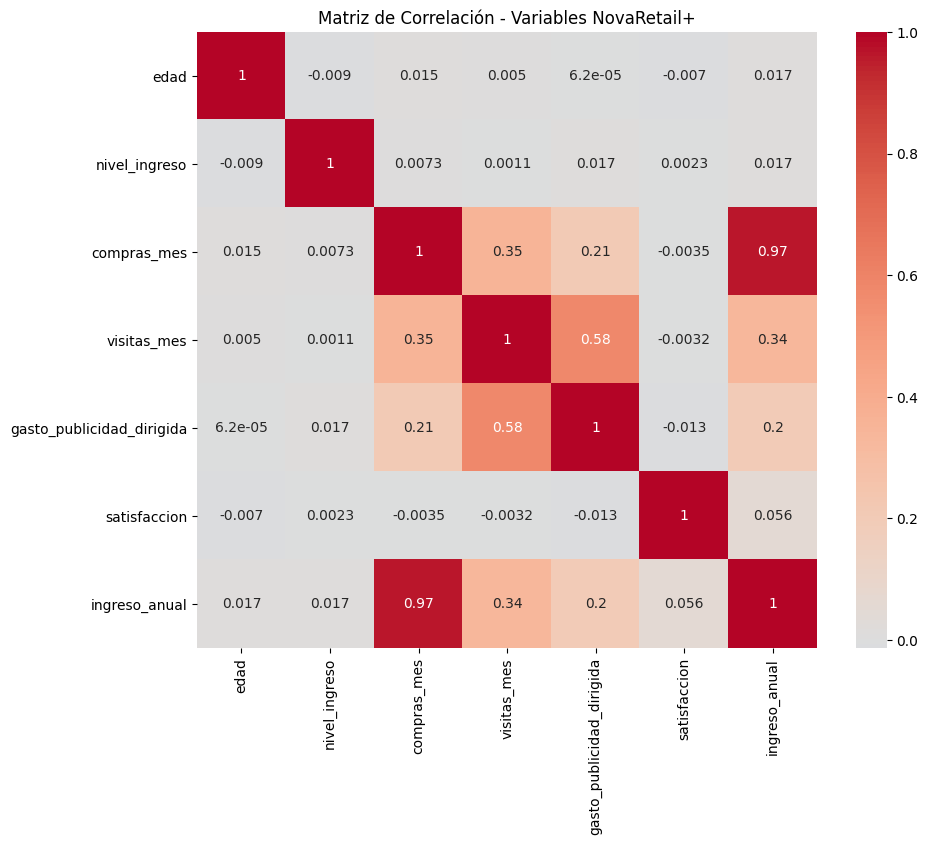

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
variables_numericas = df[['edad', 'nivel_ingreso', 'compras_mes', 'visitas_mes',
                         'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']]

# Calcular matriz de correlación
matriz_correlacion = variables_numericas.corr()

# Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Variables NovaRetail+')
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias al mapa de calor podemos apreciar las correlaciones entre las columnas, algunas claramente no tienen alguna correlación mientras que hay otras que claramente influyen en los resultados, bien hecho!
</div>


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves

**Observaciones generales (Heatmap)**  
Se observa que la mayoría de las variables presentan correlaciones bajas entre sí, lo que sugiere que no existen relaciones lineales fuertes entre muchas de las variables del dataset. Esto podría indicar que varias de las variables aportan información relativamente independiente dentro del análisis.

Destaca una correlación moderada entre visitas_mes y gasto_publicidad_dirigida (~0.58). Esta asociación podría sugerir que existe cierta relación entre el nivel de inversión publicitaria dirigida y la frecuencia de visitas a la plataforma, aunque este resultado no permite inferir una relación causal directa.

También se observa una correlación moderada entre visitas_mes y compras_mes (~0.35). Esta relación podría reflejar que los clientes con mayor nivel de interacción con la plataforma también registran una mayor frecuencia de compras, aunque nuevamente la correlación no implica necesariamente que una variable cause la otra.

Por otro lado, variables como edad, nivel_ingreso y satisfaccion muestran correlaciones muy bajas con el resto de las variables, lo que sugiere que no presentan asociaciones lineales relevantes dentro de este conjunto de datos. Esto no descarta que puedan existir relaciones más complejas o no lineales que no sean capturadas por esta matriz de correlación.

**Observaciones respecto a ingreso_anual**
La variable ingreso_anual muestra una correlación muy alta con compras_mes (~0.97). Este resultado podría sugerir una fuerte asociación entre la frecuencia de compras y el ingreso anual generado por cliente dentro del dataset. Sin embargo, es importante señalar que la correlación no permite establecer causalidad, sino únicamente la presencia de una relación lineal entre ambas variables.

Asimismo, se observa una correlación moderada entre ingreso_anual y visitas_mes (~0.34), lo que podría indicar que existe cierta asociación entre la frecuencia de visitas a la plataforma y el ingreso generado por cliente. No obstante, esta relación es considerablemente menor que la observada con la variable de compras.

En el caso de gasto_publicidad_dirigida, se identifica una correlación baja con ingreso_anual (~0.20). Esto podría sugerir que la relación lineal entre ambas variables es limitada dentro del dataset analizado, aunque sería necesario realizar análisis adicionales para comprender con mayor profundidad esta posible relación.

Finalmente, variables como edad, nivel_ingreso y satisfaccion presentan correlaciones muy bajas con ingreso_anual, lo que sugiere que no muestran una asociación lineal relevante con esta variable en el análisis de correlación realizado.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.
- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
Con base en los resultados de la matriz de correlación, no parece estrictamente necesario generar un scatterplot general para todas las variables, ya que el heatmap ya permite identificar de manera clara el nivel de asociación lineal entre ellas. La mayoría de las correlaciones observadas son bajas, por lo que un gráfico de dispersión global aportaría información limitada adicional para la interpretación general del dataset. Sí podría resultar útil analizar gráficamente algunos pares específicos de variables con mayor nivel de correlación, con el fin de complementar la interpretación del análisis exploratorio de datos.

Resulta razonable explorar mediante scatterplots las siguientes relaciones:
compras_mes vs ingreso_anual, debido a la correlación muy alta (~0.97) observada en la matriz.
visitas_mes vs gasto_publicidad_dirigida, donde se aprecia una correlación moderada (~0.58).
visitas_mes vs compras_mes, que presenta una correlación moderada (~0.35).

En estos casos, los scatterplots podrían ayudar a confirmar visualmente la forma de la relación, identificar si la asociación es realmente lineal o si existen patrones no lineales, clusters o valores extremos que no son evidentes únicamente a partir de la matriz de correlación.

### Scatterplot para pares clave

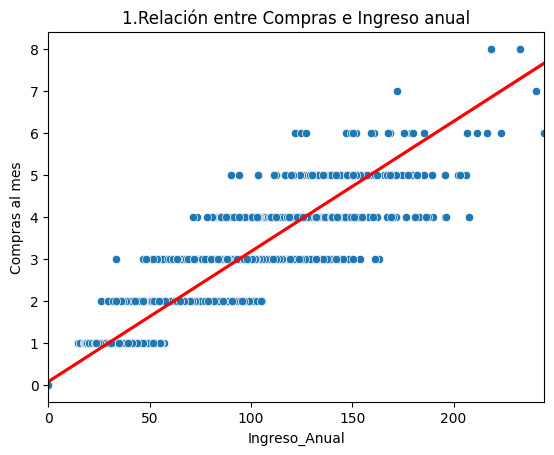

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x="ingreso_anual", y="compras_mes")
sns.regplot(data=df, x='ingreso_anual', y='compras_mes',
    scatter=False, color='red')

plt.title("1.Relación entre Compras e Ingreso anual")
plt.xlabel("Ingreso_Anual")
plt.ylabel("Compras al mes")
plt.show()


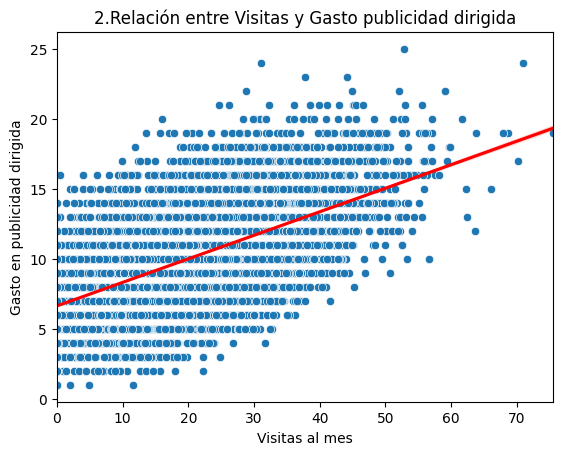

In [12]:

# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x="gasto_publicidad_dirigida", y="visitas_mes")
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes',
    scatter=False, color='red')

plt.title("2.Relación entre Visitas y Gasto publicidad dirigida")
plt.xlabel("Visitas al mes")
plt.ylabel("Gasto en publicidad dirigida")
plt.show()


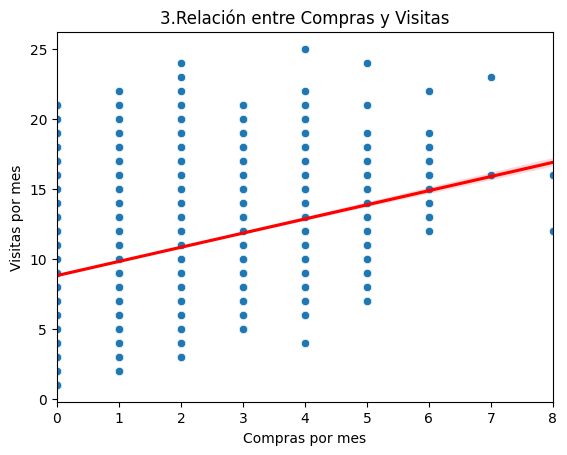

In [13]:

# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x="compras_mes", y="visitas_mes")  
sns.regplot(data=df, x='compras_mes', y='visitas_mes',
    scatter=False, color='red')

plt.title("3.Relación entre Compras y Visitas")
plt.xlabel("Compras por mes")
plt.ylabel("Visitas por mes")
plt.show()


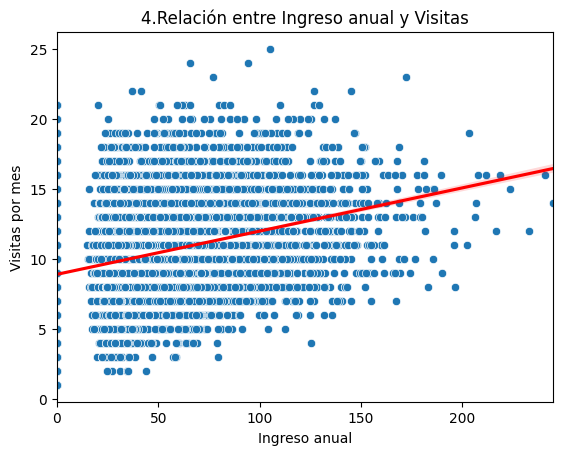

In [14]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x="ingreso_anual", y="visitas_mes")  
sns.regplot(data=df, x='ingreso_anual', y='visitas_mes',
    scatter=False, color='red')

plt.title("4.Relación entre Ingreso anual y Visitas")
plt.xlabel("Ingreso anual")
plt.ylabel("Visitas por mes")
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias a estas gráficas de disperción podemos observar claramente la correlación entre las columnas antes observadas
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

Observaciones iniciales (Scatterplot)

**Scatterplot 1**compras_mes vs ingreso_anual
**- Dirección:** Se observa una tendencia positiva, ya que a medida que aumenta el ingreso_anual, los valores de compras_mes tienden a ubicarse en niveles más altos. Esto es consistente con la alta correlación observada previamente en la matriz de correlación.
**Dispersión:** La dispersión parece relativamente baja a media, ya que muchos puntos se agrupan alrededor de una tendencia ascendente, lo que sugiere una asociación lineal relativamente fuerte entre ambas variables.
**Outliers:** No se observan valores atípicos extremos evidentes, aunque sí existen algunos puntos en niveles altos de ingreso anual con valores de compras mayores, lo cual podría representar clientes con mayor nivel de actividad.
**Posible colinealidad:** La alineación clara de los puntos alrededor de la línea de tendencia podría sugerir una relación lineal fuerte entre ambas variables, lo cual es consistente con la correlación elevada (~0.97) observada anteriormente. Esto podría indicar que ambas variables están estrechamente asociadas o potencialmente relacionadas estructuralmente dentro del dataset, aunque este gráfico por sí solo no permite establecer causalidad.

**Scatterplot 2**visitas_mes vs gasto_publicidad_dirigida
**Dirección:** Se observa una tendencia positiva, ya que a medida que aumentan las visitas_mes, los valores de gasto_publicidad_dirigida tienden a ubicarse en niveles más altos. Esto es coherente con la correlación moderada identificada previamente en el heatmap.
**Dispersión:** La dispersión de los puntos es media, ya que aunque se aprecia una tendencia ascendente general, los datos muestran una variabilidad considerable alrededor de la línea de tendencia. Esto sugiere que la relación entre ambas variables no es perfectamente lineal.
**Outliers:** No se identifican outliers extremos claramente definidos, aunque existen algunos puntos en valores altos de visitas o gasto que se separan ligeramente del resto de la nube de puntos.
**Posible colinealidad:** La presencia de una tendencia ascendente moderada podría indicar una asociación lineal moderada entre ambas variables, aunque la dispersión observada sugiere que la relación no es lo suficientemente fuerte como para indicar una colinealidad elevada. Además, como en cualquier análisis de correlación, esta relación no implica necesariamente causalidad.

**Scatterplot 3** compras_mes vs visitas_mes
**Dirección:** positiva. A mayor número de compras por mes, tiende a observarse un mayor número de visitas por mes.
**Dispersión:** media. Los puntos se distribuyen alrededor de la línea de tendencia con cierta variabilidad, lo que sugiere que la relación no es perfectamente lineal.
**Outliers:** no se observan outliers extremos evidentes.
**Posible colinealidad:** la relación parece moderada, lo que indica asociación entre las variables, pero no una colinealidad fuerte.

**Scatterplot 4** ingreso_anual vs visitas_mes
**Dirección:** Se observa una relación positiva, ya que a medida que aumenta el ingreso anual, también tiende a aumentar el número de visitas por mes.
**Dispersión:** La dispersión es media, ya que los puntos se distribuyen alrededor de la línea de tendencia con una variabilidad moderada.
**Outliers:** No se observan outliers extremos claros, aunque existen algunos valores ligeramente alejados del grupo principal.
**Posible colinealidad:** La relación parece moderada, lo que indica cierta asociación entre las variables, pero no evidencia de una colinealidad fuerte.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [15]:
# Calcular correlación entre variables relevantes
corr_matriz = variables_numericas.corr(method="pearson")
corr_matriz

,edad,nivel_ingreso,compras_mes,visitas_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.009003,0.014971,0.004998,0.000062,-0.006963,0.017496
nivel_ingreso,-0.009003,1.000000,0.007309,0.001060,0.016834,0.002301,0.017446
compras_mes,0.014971,0.007309,1.000000,0.353844,0.207528,-0.003542,0.967149
visitas_mes,0.004998,0.001060,0.353844,1.000000,0.578947,-0.003179,0.337147
gasto_publicidad_dirigida,0.000062,0.016834,0.207528,0.578947,1.000000,-0.013175,0.197483
satisfaccion,-0.006963,0.002301,-0.003542,-0.003179,-0.013175,1.000000,0.056171
ingreso_anual,0.017496,0.017446,0.967149,0.337147,0.197483,0.056171,1.000000


In [16]:
# Para ver específicamente las correlaciones con ingreso_anual
correlaciones_ingreso = corr_matriz['ingreso_anual'].sort_values(ascending=False)
print("Correlaciones con ingreso_anual (ordenadas de mayor a menor):")
correlaciones_ingreso

Correlaciones con ingreso_anual (ordenadas de mayor a menor):


ingreso_anual                1.000000
compras_mes                  0.967149
visitas_mes                  0.337147
gasto_publicidad_dirigida    0.197483
satisfaccion                 0.056171
edad                         0.017496
nivel_ingreso                0.017446
Name: ingreso_anual, dtype: float64

In [17]:
# Calcular correlación entre variables relevantes
corr_matriz = variables_numericas.corr(method="spearman")
corr_matriz

,edad,nivel_ingreso,compras_mes,visitas_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.007775,0.015630,0.005205,0.002869,-0.007590,0.016097
nivel_ingreso,-0.007775,1.000000,0.009004,0.001420,0.015393,0.005243,0.025017
compras_mes,0.015630,0.009004,1.000000,0.332943,0.192511,-0.002006,0.967482
visitas_mes,0.005205,0.001420,0.332943,1.000000,0.559267,-0.001305,0.320954
gasto_publicidad_dirigida,0.002869,0.015393,0.192511,0.559267,1.000000,-0.012612,0.184999
satisfaccion,-0.007590,0.005243,-0.002006,-0.001305,-0.012612,1.000000,0.060834
ingreso_anual,0.016097,0.025017,0.967482,0.320954,0.184999,0.060834,1.000000


In [19]:
# Para ver específicamente las correlaciones con ingreso_anual
correlaciones_ingreso = corr_matriz['ingreso_anual'].sort_values(ascending=False)
print("Correlaciones con ingreso_anual (ordenadas de mayor a menor):")
correlaciones_ingreso

Correlaciones con ingreso_anual (ordenadas de mayor a menor):


ingreso_anual                1.000000
compras_mes                  0.967482
visitas_mes                  0.320954
gasto_publicidad_dirigida    0.184999
satisfaccion                 0.060834
nivel_ingreso                0.025017
edad                         0.016097
Name: ingreso_anual, dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  

Incluye qué ves: dirección, magnitud y posible colinealidad.

Observaciones de correlación
**ingreso_anual vs compras_mes**
Correlación: muy fuerte y positiva (Pearson ≈ 0.97, Spearman ≈ 0.97). Esto indica que a mayor ingreso anual, mayor número de compras por mes. La similitud entre ambos coeficientes sugiere una relación lineal consistente y posible colinealidad fuerte entre las variables.

**ingreso_anual vs visitas_mes**
Correlación: positiva moderada (Pearson ≈ 0.34, Spearman ≈ 0.32). Esto indica que los clientes con mayor ingreso tienden a realizar más visitas, aunque la relación no es tan fuerte como con las compras.

**ingreso_anual vs gasto_publicidad_dirigida**
Correlación: positiva débil (Pearson ≈ 0.20, Spearman ≈ 0.18). Esto sugiere que el gasto en publicidad dirigida tiene una asociación limitada con el ingreso anual.

**ingreso_anual vs satisfaccion**
Correlación: positiva muy débil (Pearson = 0.0562, Spearman = 0.0608). Esto sugiere que el nivel de satisfacción no presenta una relación significativa con el ingreso anual.

**ingreso_anual vs nivel_ingreso**
Correlación: positiva prácticamente nula (Pearson = 0.0174, Spearman = 0.0250). La relación es muy baja, lo que indica que no existe asociación relevante entre estas variables en el dataset.

**ingreso_anual vs edad**
Correlación: casi nula (Pearson = 0.0175, Spearman = 0.0161). Esto sugiere que la edad no presenta una relación significativa con el ingreso anual en este conjunto de datos.

**Comparación Pearson vs Spearman**
Las diferencias entre ambos coeficientes son muy pequeñas, lo que indica que las relaciones observadas son relativamente estables y no están fuertemente influenciadas por outliers o relaciones no lineales.

### Punto-biserial

In [20]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

def corr_point_biserial(df, variables_binarias, variables_numericas):

        for col in variables_numericas:
            coef, p_value = pointbiserialr(df[variables_binarias],df[col])

            print(f"\nCorrelacion entre: {variables_binarias} y {col}")
            print(f"Point-Biserial: {coef:.4f}")

In [21]:
# Calcular correlación entre variables relevantes

def mostrar_por_grupos(df, variables_binarias, variables_numericas):
    """
    Muestra resultados agrupados por variable binaria, ordenados por correlación
    """
    for var_binaria in variables_binarias:
        print(f"\n{'='*50}")
        print(f"CORRELACIONES CON: {var_binaria.upper()}")
        print(f"{'='*50}")
        
        resultados_grupo = []
        for var_numerica in variables_numericas:
            coef, p_value = pointbiserialr(df[var_binaria], df[var_numerica])
            resultados_grupo.append((var_numerica, coef, p_value))
        
        # Ordenar por magnitud de correlación
        resultados_grupo.sort(key=lambda x: abs(x[1]), reverse=True)
        
        for var, coef, p_val in resultados_grupo:
            print(f"{var}: {coef:.4f}")

# Ejecutar
mostrar_por_grupos(df, variables_binarias, variables_numericas)


CORRELACIONES CON: MIEMBRO_PREMIUM
ingreso_anual: 0.0931
satisfaccion: 0.0257
visitas_mes: -0.0127
nivel_ingreso: -0.0056
edad: 0.0046
compras_mes: 0.0034
gasto_publicidad_dirigida: 0.0027

CORRELACIONES CON: ABANDONO
satisfaccion: -0.0238
edad: -0.0115
visitas_mes: -0.0089
compras_mes: 0.0083
nivel_ingreso: 0.0059
gasto_publicidad_dirigida: -0.0046
ingreso_anual: -0.0028


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial
Las correlaciones punto-biseriales presentan magnitudes muy bajas, lo que sugiere que ninguna variable numérica muestra una asociación fuerte con miembro_premium o abandono. Esto podría indicar que estas variables dependen de factores adicionales o combinaciones de variables no capturadas en este análisis.
Las asociaciones observadas son débiles y no sugieren relaciones relevantes entre las variables analizadas.

**Relación con miembro_premium**
-ingreso_anual: relación positiva débil (≈ 0.093). Sugiere una ligera asociación entre mayores ingresos y membresía premium.
-satisfaccion: relación positiva muy débil (≈ 0.026). Asociación prácticamente irrelevante.
-visitas_mes: relación negativa muy débil (≈ −0.013). Asociación prácticamente nula.
-nivel_ingreso: relación negativa casi nula (≈ −0.006). No se observa asociación relevante.
-edad: relación positiva casi nula (≈ 0.005). Asociación inexistente en términos prácticos.
-compras_mes: relación positiva casi nula (≈ 0.003). No se identifica relación significativa.
-gasto_publicidad_dirigida: relación positiva casi nula (≈ 0.003). Asociación prácticamente inexistente.

**Relación con abandono**
-satisfaccion: relación negativa muy débil (≈ −0.024). Podría sugerir que mayor satisfacción se asocia ligeramente con menor abandono.
-edad: relación negativa muy débil (≈ −0.012). Asociación prácticamente nula.
-visitas_mes: relación negativa muy débil (≈ −0.009). Asociación mínima.
-compras_mes: relación positiva muy débil (≈ 0.008). Asociación prácticamente inexistente.
-nivel_ingreso: relación positiva casi nula (≈ 0.006). Sin asociación relevante.
-gasto_publicidad_dirigida: relación negativa casi nula (≈ −0.005). Asociación insignificante.
-ingreso_anual: relación negativa casi nula (≈ −0.003). No se observa relación relevante.


### V de Cramér

In [22]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # Tabla de contingencia
    tabla = pd.crosstab(x, y)
    # Calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla) 
    # Número de observaciones
    n = tabla.sum().sum()
    # Calcular V de Cramér
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

    return v

In [23]:
# Crear tabla de contingencia
tabla = pd.crosstab(df["tipo_dispositivo"], df["region"])
print("\n=== Tabla de Contingencia ===")
print(tabla)


=== Tabla de Contingencia ===
region            este  norte  oeste   sur
tipo_dispositivo                          
escritorio         766   1125    935   894
móvil             2003   2843   2489  2483
tablet             300    427    386   349


In [24]:
# Calcular la V de Cramér
chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

print("=== RESULTADOS DEL ANÁLISIS ===")
print(f"Chi2: {chi2:.4f}")
print(f"Valor p: {p:.4f}")
print(f"Grados de libertad: {dof}")
print(f"V de Cramér: {cramers_v:.4f}")

=== RESULTADOS DEL ANÁLISIS ===
Chi2: 4.5967
Valor p: 0.5965
Grados de libertad: 6
V de Cramér: 0.0124


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las coeficientes de correlación y asociación de la sección 4 fueron correctamente aplicados, bien hecho!
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
El análisis Chi-cuadrado entre tipo_dispositivo y region arroja un valor de χ² = 4.60 con p = 0.596. Dado que el valor p es mayor a 0.05, no se observa evidencia estadística suficiente para afirmar que exista asociación entre ambas variables. Asimismo, el valor de Cramér's V = 0.012 indica que la fuerza de la relación es prácticamente inexistente.
La distribución del tipo de dispositivo es relativamente uniforme entre las regiones analizadas, lo que se refleja en un valor muy bajo de Cramér's V (0.012). Esto sugiere ausencia de asociación relevante entre ambas variables.No hay evidencia estadística de relación entre las variables categóricas analizadas: tipo_dispositivo y region parecen comportarse de forma independiente en el dataset.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — Frecuencia de compra e ingreso 

**Evidencia visual:**   
Heatmap de correlación y Scatterplot (Compras vs. Ingreso).

**Evidencia numérica:** 
Correlación de Pearson ≈ 0.97 (muy fuerte y positiva).
Coeficiente de Pearson: 0.9671 | Coeficiente de Spearman: 0.9675.

**Interpretación**  
Se observa una asociación positiva muy fuerte entre el número de compras mensuales y el ingreso anual generado por cliente. Esto sugiere que los clientes que compran con mayor frecuencia tienden a concentrar una mayor generación de ingresos dentro del dataset.

**No podemos afirmar**  
No es posible afirmar que aumentar el número de compras cause directamente un incremento en el ingreso anual, ya que el análisis es correlacional y no controla otros factores como precio promedio, promociones o tipo de producto.


**Implicación de negocio**  
La frecuencia de compra podría ser una métrica relevante para identificar clientes de alto valor. El negocio podría explorar estrategias enfocadas en incrementar la recurrencia de compra o retener clientes que ya presentan alta frecuencia, evaluando su impacto mediante experimentos o análisis adicionales.

### Hallazgo 2 — Visitas a la plataforma e ingreso anual

**Evidencia visual:**   
Scatterplot entre visitas_mes e ingreso_anual.
Heatmap de correlación

**Evidencia numérica:** 
Correlación de Pearson ≈ 0.34 (positiva moderada).

**Interpretación**  
Se observa una asociación positiva moderada entre el número de visitas mensuales y el ingreso anual generado por cliente. Esto sugiere que los usuarios que interactúan con mayor frecuencia con la plataforma tienden a generar mayores niveles de ingreso dentro del dataset.

**No podemos afirmar**  
El análisis no permite afirmar que incrementar las visitas cause directamente un aumento en los ingresos, ya que podrían influir otros factores como promociones, intención de compra o características del cliente.

**Implicación de negocio**  
Las visitas podrían representar una métrica relevante de engagement. El negocio podría explorar estrategias orientadas a aumentar la interacción de los usuarios con la plataforma y evaluar posteriormente si esto se traduce en mayores ingresos.

### Hallazgo 3 — Publicidad dirigida e ingreso generado

**Evidencia visual:**   
Heatmap de correlaciones y scatterplot entre gasto_publicidad_dirigida e ingreso_anual.

**Evidencia numérica:** 
Correlación de Pearson ≈ 0.20 (positiva débil).

**Interpretación**  
Se observa una asociación positiva débil entre el gasto en publicidad dirigida y el ingreso anual generado por cliente. Esto podría sugerir que los clientes expuestos a mayores niveles de publicidad tienden a generar ligeramente más ingresos, aunque la magnitud de la relación es limitada.

**No podemos afirmar**  
No es posible concluir que aumentar el gasto en publicidad dirigida genere directamente mayores ingresos, ya que la relación observada es débil y podrían intervenir otros factores como el perfil del cliente, la frecuencia de compra o el tipo de producto adquirido.

**Implicación de negocio**  
La publicidad dirigida podría contribuir al ingreso, pero probablemente no sea el principal driver del revenue. Sería recomendable analizar su efecto en combinación con variables de comportamiento del cliente, como frecuencia de compra o engagement con la plataforma.

### Hallazgo 4 — Visitas a la plataforma y comportamiento de compra

**Evidencia visual:**   
Scatterplot entre visitas_mes y compras_mes.
Heatmap de correlación 

**Evidencia numérica:** 
Correlación de Pearson ≈ 0.33 (positiva moderada).

**Interpretación**  
Se observa una asociación positiva moderada entre el número de visitas mensuales y la cantidad de compras realizadas. Esto podría sugerir que los usuarios que interactúan más frecuentemente con la plataforma también tienden a registrar un mayor número de compras.

**No podemos afirmar**  
No es posible concluir que aumentar las visitas genere directamente más compras, ya que podrían intervenir otros factores como promociones, intención previa de compra o características del usuario.

**Implicación de negocio**  
Podría ser útil explorar estrategias que incrementen el engagement previo a la compra (por ejemplo, recomendaciones personalizadas o recordatorios), evaluando posteriormente su efecto real mediante pruebas controladas. Sería recomendable investigar fricciones en el embudo de ventas (Checkout) para convertir el tráfico existente en compras efectivas.


### Hallazgo 5 — Variables demográficas e ingreso anual

**Evidencia visual:**   
Heatmap de correlaciones.

**Evidencia numérica:** 
Correlaciones con ingreso_anual:
edad ≈ 0.02
nivel_ingreso ≈ 0.02
satisfaccion ≈ 0.06
(magnitud muy baja o prácticamente nula).

**Interpretación**  
Las variables demográficas analizadas presentan asociaciones muy bajas con el ingreso anual. Esto sugiere que, dentro de este dataset, factores como edad o nivel de ingreso no muestran una relación clara con la generación de ingresos por cliente.

**No podemos afirmar**  
No es posible concluir que estas variables no influyan en el ingreso en otros contextos o datasets, ya que el análisis se limita a las variables disponibles y a las relaciones lineales observadas.

**Implicación de negocio**  
Estos resultados podrían indicar que el comportamiento del usuario dentro de la plataforma (visitas, compras) tiene mayor relación con el ingreso generado que las características demográficas del cliente.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las observaciones que haces me parecen bien explicadas, además estan en un formato correcto
</div>

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad: Los hallazgos muestran asociaciones, pero no garantizan que cambiar una variable (como subir la satisfacción) cause un aumento inmediato en los ingresos.
- El análisis realizado es correlacional, por lo que no permite establecer relaciones causales entre las variables.
- Algunas variables potencialmente relevantes no están incluidas en el dataset, como:
historial de promociones, antigüedad del cliente, tipo de productos adquiridos.
- Las relaciones observadas podrían variar al analizar segmentos específicos de clientes.
- Datos Estáticos: El dataset es una "foto" del cierre de 2024; no considera la estacionalidad (ej. Black Friday o promociones específicas).
- Variables ausentes: No se cuenta con la antigüedad del cliente, ni con el tipo de categorías de productos comprados, lo cual podría matizar la relación con el ingreso.

### **Próximos pasos** 

Probar segmentación adicional
- Análisis de segmentación de clientes
Explorar el comportamiento de compra por segmentos como región, tipo de dispositivo o nivel de ingreso, para identificar perfiles de clientes con mayor valor potencial.

- Análisis Regional: Investigar por qué la región Norte es la más activa y si las estrategias usadas allí son replicables en la región Este.

- Análisis de abandono (churn)
Profundizar en la variable abandono mediante modelos predictivos o análisis de cohortes para identificar posibles factores asociados a la retención de clientes.

- Evaluación mediante experimentos
Diseñar pruebas A/B para validar si estrategias orientadas a aumentar visitas o engagement generan cambios reales en la frecuencia de compra o en los ingresos.

-Optimización de Publicidad:
Cruzar el gasto_publicidad_dirigida con la satisfaccion para verificar si la saturación publicitaria está afectando la percepción de marca en ciertos segmentos.

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar que la correlación no siempre indica causalidad.<br/>    
<br/>    
Te felicito por el buen trabajo que has hecho, continúa así y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- El proyecto esta ordenado
- El proyecto es directo y conciso
- Se revisaron detalles muy minuciosamente con bastante cuidado
    
</div> 
